# Hail M0 - MYRORSS Source Qualification - Reconcile Selected-Cell Batches

**Peril:** hail - **Layer:** M0 input evidence - **Mode:** common source qualification with a
CONUS-grid selected-cell adapter proof

This notebook is the QA gate after `03_selected_cell_full_record_batches`. It does not scan new MYRORSS
source files. It reads completed chronological batch artifacts, validates which batches are clean, and
produces one partial selected-cell MYRORSS daily panel.

## Step back - why this notebook exists

The batch scanner intentionally writes one artifact set per date window. That is the right execution shape,
but M1 cannot consume a pile of batch files directly. Before running many more batches, we need to prove the
reconciliation layer:

```text
completed planned batches
  -> validate metadata and source-file QA
  -> reject dirty/incomplete batches
  -> concatenate selected-cell daily panels
  -> prove date/cell completeness and no duplicate rows
  -> write partial MYRORSS-era panel + QA summary
```

Source roles stay strict:

- **MYRORSS:** gridded evidence source being reconciled.
- **NOAA Storm Events / SPC:** not joined here.
- **MRMS:** not joined here.
- **NRI:** not joined here.

This proves the reconciliation gate. It is not, by itself, permission for larger local runs or GCP-scale
orchestration; that still needs the source-promotion gate documented.

Plan links:

- `docs/plans/hazard_conus_grid/hail/m0_m1_hazard_layer.md`
- `docs/learning_logs/conus_grid/02_raw_gridded_sources_need_batch_denominators.md`
- `docs/principles/notebook_work/exploratory_data_notebooks.md`

## 0 - Scope and non-goals

This notebook does:

1. Read the 14-day batch plan and completed batch metadata files.
2. Keep only planned, non-proof batches with clean metadata and existing outputs.
3. Validate each accepted batch: date range, source-file failures, row counts, duplicate keys, and selected
   cell coverage.
4. Concatenate clean daily panels and day manifests.
5. Check partial-panel date continuity and one row per selected cell per date.
6. Write reconciled partial artifacts.

It deliberately does **not**:

- scan new MYRORSS files;
- use report-guided data;
- merge MYRORSS with MRMS;
- estimate final annual frequency;
- produce final M1, EAL, VaR, PML, or TVaR.

The carried-forward object is a **partial MYRORSS selected-cell daily panel**, still marked not-final.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 115})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"
OUTPUT_VERSION = "v2026_06_16"

BATCH_PLAN_CSV = HAIL_GRID_DIR / f"myrorss_m0_selected_cell_full_record_batch_plan_{OUTPUT_VERSION}.csv"
SELECTED_CELLS_CSV = HAIL_GRID_DIR / "selected_pilot_cells_v2026_06_16.csv"

print("repo root:", ROOT)
print("batch plan:", BATCH_PLAN_CSV.relative_to(ROOT))
print("selected cells:", SELECTED_CELLS_CSV.relative_to(ROOT))

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
batch plan: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_full_record_batch_plan_v2026_06_16.csv
selected cells: data/hazard_conus_grid/hail/selected_pilot_cells_v2026_06_16.csv


## 1 - Load selected cells and planned batch windows

The batch plan is the source of truth for what counts as a planned chronological batch. The two-day proof
batch is intentionally excluded because it does not match a planned 14-day window and overlaps batch 0001.

In [2]:
selected_cells = pd.read_csv(SELECTED_CELLS_CSV)
selected_cells = selected_cells[
    ["hazard", "selection_version", "role", "cell_id", "lat_center", "lon_center", "state_abbr", "iso_rto"]
].copy()
selected_cells["cell_id"] = selected_cells["cell_id"].astype(int)
selected_ids = set(selected_cells["cell_id"])

batch_plan = pd.read_csv(BATCH_PLAN_CSV)
batch_plan["batch_number"] = batch_plan["batch_id"].str.extract(r"_(\d+)$").astype(int)
batch_plan["batch_label"] = (
    batch_plan["batch_start"].str.replace("-", "", regex=False)
    + "_"
    + batch_plan["batch_end"].str.replace("-", "", regex=False)
)
planned_by_label = batch_plan.set_index("batch_label").to_dict(orient="index")

display(selected_cells)
display(batch_plan.head(8))
print("planned batches:", len(batch_plan))
print("selected cells:", len(selected_ids))

,hazard,selection_version,role,cell_id,lat_center,lon_center,state_abbr,iso_rto
0,hail,v2026_06_16,high_hail,329354,33.00,-101.50,TX,ERCOT
1,hail,v2026_06_16,medium_hail,261700,44.75,-95.00,MN,MISO
2,hail,v2026_06_16,low_hail,247197,47.25,-120.75,WA,WEIM
3,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT


,batch_id,batch_start,batch_end,n_days,source,source_product,planned_role,allowed_use,batch_number,batch_label
0,myrorss_selected_cell_0001,1998-05-01,1998-05-14,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output,1,19980501_19980514
1,myrorss_selected_cell_0002,1998-05-15,1998-05-28,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output,2,19980515_19980528
2,myrorss_selected_cell_0003,1998-05-29,1998-06-11,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output,3,19980529_19980611
3,myrorss_selected_cell_0004,1998-06-12,1998-06-25,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output,4,19980612_19980625
4,myrorss_selected_cell_0005,1998-06-26,1998-07-09,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output,5,19980626_19980709
5,myrorss_selected_cell_0006,1998-07-10,1998-07-23,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output,6,19980710_19980723
6,myrorss_selected_cell_0007,1998-07-24,1998-08-06,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output,7,19980724_19980806
7,myrorss_selected_cell_0008,1998-08-07,1998-08-20,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output,8,19980807_19980820


planned batches: 357
selected cells: 4


## 2 - Discover completed metadata files

Metadata controls whether a batch is eligible. We only accept batches that:

- match a row in the planned batch CSV;
- are not the two-day proof batch;
- have all referenced output files present;
- have zero read failures;
- have an execution window that matches the batch plan.

In [3]:
metadata_paths = sorted(HAIL_GRID_DIR.glob(f"myrorss_m0_selected_cell_full_record_metadata_*_{OUTPUT_VERSION}.json"))


def relative(path: Path) -> str:
    return str(path.relative_to(ROOT))


def load_metadata(path: Path) -> dict:
    data = json.loads(path.read_text())
    data["_metadata_path"] = path
    return data


def classify_metadata(metadata: dict) -> dict[str, object]:
    execution = metadata.get("execution_batch", {})
    coverage = metadata.get("scan_coverage", {})
    outputs = metadata.get("outputs", {})
    label = execution.get("batch_label")
    plan_row = planned_by_label.get(label)

    output_paths = {
        name: ROOT / value
        for name, value in outputs.items()
        if name.endswith("_csv")
    }
    missing_outputs = [name for name, path in output_paths.items() if not path.exists()]

    status = "clean_for_reconcile"
    reasons: list[str] = []
    if plan_row is None:
        status = "skip_not_in_batch_plan"
        reasons.append("metadata batch label is not a planned batch window")
    else:
        if execution.get("start") != plan_row["batch_start"]:
            status = "skip_plan_mismatch"
            reasons.append("execution start does not match plan")
        if execution.get("end") != plan_row["batch_end"]:
            status = "skip_plan_mismatch"
            reasons.append("execution end does not match plan")
        if int(execution.get("n_days", -1)) != int(plan_row["n_days"]):
            status = "skip_plan_mismatch"
            reasons.append("execution day count does not match plan")

    if execution.get("default_proof_batch"):
        status = "skip_proof_batch"
        reasons.append("proof batch is not a planned full-record batch")
    if missing_outputs:
        status = "skip_missing_outputs"
        reasons.append("missing outputs: " + ", ".join(missing_outputs))
    if int(coverage.get("n_read_failures_total", 0)) != 0:
        status = "skip_read_failures"
        reasons.append(f"read failures: {coverage.get('n_read_failures_total')}")

    return {
        "metadata_path": relative(metadata["_metadata_path"]),
        "batch_label": label,
        "batch_id": plan_row["batch_id"] if plan_row else None,
        "batch_number": int(plan_row["batch_number"]) if plan_row else np.nan,
        "batch_start": execution.get("start"),
        "batch_end": execution.get("end"),
        "n_days": execution.get("n_days"),
        "n_source_files_total": coverage.get("n_source_files_total"),
        "n_empty_source_files_total": coverage.get("n_empty_source_files_total"),
        "n_read_failures_total": coverage.get("n_read_failures_total"),
        "status": status,
        "reason": "; ".join(reasons),
        "day_manifest_csv": outputs.get("day_manifest_csv"),
        "daily_panel_csv": outputs.get("daily_panel_csv"),
        "summary_csv": outputs.get("summary_csv"),
    }


metadata_records = [classify_metadata(load_metadata(path)) for path in metadata_paths]
batch_inventory = pd.DataFrame(metadata_records).sort_values(
    ["status", "batch_number", "batch_start"], na_position="last"
)
display(batch_inventory)

accepted_batches = (
    batch_inventory.query("status == 'clean_for_reconcile'")
    .sort_values("batch_number")
    .reset_index(drop=True)
)
display(accepted_batches)

print("metadata files found:", len(batch_inventory))
print("clean planned batches accepted:", len(accepted_batches))

,metadata_path,batch_label,batch_id,batch_number,batch_start,batch_end,n_days,n_source_files_total,n_empty_source_files_total,n_read_failures_total,status,reason,day_manifest_csv,daily_panel_csv,summary_csv
1,data/hazard_conus_grid/hail/myrorss_m0_selecte...,19980501_19980514,myrorss_selected_cell_0001,1.0,1998-05-01,1998-05-14,14,4144,0,0,clean_for_reconcile,,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...
2,data/hazard_conus_grid/hail/myrorss_m0_selecte...,19980515_19980528,myrorss_selected_cell_0002,2.0,1998-05-15,1998-05-28,14,4144,0,0,clean_for_reconcile,,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...
3,data/hazard_conus_grid/hail/myrorss_m0_selecte...,19980529_19980611,myrorss_selected_cell_0003,3.0,1998-05-29,1998-06-11,14,4144,0,0,clean_for_reconcile,,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...
0,data/hazard_conus_grid/hail/myrorss_m0_selecte...,19980501_19980502,NaN,NaN,1998-05-01,1998-05-02,2,592,0,0,skip_proof_batch,metadata batch label is not a planned batch wi...,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...


,metadata_path,batch_label,batch_id,batch_number,batch_start,batch_end,n_days,n_source_files_total,n_empty_source_files_total,n_read_failures_total,status,reason,day_manifest_csv,daily_panel_csv,summary_csv
0,data/hazard_conus_grid/hail/myrorss_m0_selecte...,19980501_19980514,myrorss_selected_cell_0001,1.0,1998-05-01,1998-05-14,14,4144,0,0,clean_for_reconcile,,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...
1,data/hazard_conus_grid/hail/myrorss_m0_selecte...,19980515_19980528,myrorss_selected_cell_0002,2.0,1998-05-15,1998-05-28,14,4144,0,0,clean_for_reconcile,,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...
2,data/hazard_conus_grid/hail/myrorss_m0_selecte...,19980529_19980611,myrorss_selected_cell_0003,3.0,1998-05-29,1998-06-11,14,4144,0,0,clean_for_reconcile,,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...,data/hazard_conus_grid/hail/myrorss_m0_selecte...


metadata files found: 4
clean planned batches accepted: 3


**Takeaway.** Reconciliation starts by rejecting anything ambiguous. The proof batch is useful history, but
it is not allowed into the planned partial panel because it overlaps the first 14-day planned batch.

## 3 - Validate and load accepted batch artifacts

Each clean batch still gets checked after metadata classification. This protects against file drift,
duplicate row keys, and accidental row loss.

In [4]:
def expected_dates(start: str, end: str) -> list[str]:
    return [d.date().isoformat() for d in pd.date_range(start, end, freq="D")]


def validate_batch_row(batch: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, object]]:
    manifest_path = ROOT / str(batch["day_manifest_csv"])
    panel_path = ROOT / str(batch["daily_panel_csv"])

    day_manifest = pd.read_csv(manifest_path)
    panel = pd.read_csv(panel_path)
    dates = expected_dates(batch["batch_start"], batch["batch_end"])

    issues: list[str] = []
    if day_manifest["date"].tolist() != dates:
        issues.append("day_manifest dates are not exactly the expected continuous range")
    if sorted(panel["date"].unique().tolist()) != dates:
        issues.append("panel dates are not exactly the expected continuous range")
    if day_manifest["n_read_failures"].sum() != 0:
        issues.append("day_manifest has read failures")
    if panel["n_read_failures"].sum() != 0:
        issues.append("panel has read failures")
    if len(panel) != len(dates) * len(selected_ids):
        issues.append("panel row count is not dates x selected cells")
    if panel.duplicated(["cell_id", "date"]).any():
        issues.append("panel has duplicate cell_id/date rows")
    if set(panel["cell_id"].astype(int)) != selected_ids:
        issues.append("panel selected cell set does not match selected manifest")
    if set(panel["batch_label"]) != {batch["batch_label"]}:
        issues.append("panel batch_label mismatch")
    if set(day_manifest["batch_label"]) != {batch["batch_label"]}:
        issues.append("day_manifest batch_label mismatch")

    if issues:
        raise ValueError(f"{batch['batch_id']} failed validation: {'; '.join(issues)}")

    stats = {
        "batch_id": batch["batch_id"],
        "batch_label": batch["batch_label"],
        "batch_number": int(batch["batch_number"]),
        "batch_start": batch["batch_start"],
        "batch_end": batch["batch_end"],
        "n_days": int(batch["n_days"]),
        "n_source_files": int(day_manifest["n_source_files"].sum()),
        "n_empty_source_files": int(day_manifest["n_empty_source_files"].sum()),
        "n_read_failures": int(day_manifest["n_read_failures"].sum()),
        "n_panel_rows": int(len(panel)),
        "n_exact_hail_days": int(panel["hail_day_flag"].sum()),
        "n_neighbor_3x3_hail_days": int(panel["neighbor_3x3_hail_day_flag"].sum()),
        "max_exact_mesh_mm": float(panel["mesh_max_mm"].max()) if panel["mesh_max_mm"].notna().any() else np.nan,
        "max_neighbor_3x3_mesh_mm": float(panel["neighbor_3x3_mesh_max_mm"].max())
        if panel["neighbor_3x3_mesh_max_mm"].notna().any()
        else np.nan,
    }
    return day_manifest, panel, stats


day_manifest_frames: list[pd.DataFrame] = []
panel_frames: list[pd.DataFrame] = []
batch_stats: list[dict[str, object]] = []

for _, batch in accepted_batches.iterrows():
    day_manifest, panel, stats = validate_batch_row(batch)
    day_manifest_frames.append(day_manifest)
    panel_frames.append(panel)
    batch_stats.append(stats)

reconciled_day_manifest = pd.concat(day_manifest_frames, ignore_index=True)
reconciled_panel = pd.concat(panel_frames, ignore_index=True)
batch_manifest = pd.DataFrame(batch_stats).sort_values("batch_number").reset_index(drop=True)

display(batch_manifest)

,batch_id,batch_label,batch_number,batch_start,batch_end,n_days,n_source_files,n_empty_source_files,n_read_failures,n_panel_rows,n_exact_hail_days,n_neighbor_3x3_hail_days,max_exact_mesh_mm,max_neighbor_3x3_mesh_mm
0,myrorss_selected_cell_0001,19980501_19980514,1,1998-05-01,1998-05-14,14,4144,0,0,56,0,0,6.301800,9.123694
1,myrorss_selected_cell_0002,19980515_19980528,2,1998-05-15,1998-05-28,14,4144,0,0,56,0,1,1.150887,33.943497
2,myrorss_selected_cell_0003,19980529_19980611,3,1998-05-29,1998-06-11,14,4144,0,0,56,0,0,2.896280,21.426476


**Takeaway.** The accepted batches pass the per-batch contract: complete date ranges, one selected-cell row
per date, no duplicate keys, and zero read failures.

## 4 - Validate the reconciled partial panel

Now the cross-batch checks matter: no overlap, no gaps inside the accepted window, and exactly one row per
selected cell per date.

In [5]:
reconciled_panel["date"] = pd.to_datetime(reconciled_panel["date"]).dt.date.astype(str)
reconciled_day_manifest["date"] = pd.to_datetime(reconciled_day_manifest["date"]).dt.date.astype(str)

panel_start = reconciled_panel["date"].min()
panel_end = reconciled_panel["date"].max()
RECON_LABEL = f"{panel_start.replace('-', '')}_{panel_end.replace('-', '')}"

all_expected_dates = expected_dates(panel_start, panel_end)
actual_dates = sorted(reconciled_panel["date"].unique().tolist())
missing_dates = sorted(set(all_expected_dates) - set(actual_dates))
extra_dates = sorted(set(actual_dates) - set(all_expected_dates))
duplicate_panel_rows = int(reconciled_panel.duplicated(["cell_id", "date"]).sum())

date_cell_grid = pd.MultiIndex.from_product(
    [sorted(selected_ids), all_expected_dates],
    names=["cell_id", "date"],
).to_frame(index=False)
present_keys = reconciled_panel[["cell_id", "date"]].copy()
present_keys["present"] = True
missing_cell_dates = date_cell_grid.merge(present_keys, on=["cell_id", "date"], how="left")
missing_cell_dates = missing_cell_dates[missing_cell_dates["present"].isna()].drop(columns=["present"])

reconcile_checks = pd.DataFrame(
    [
        ("accepted_batches", len(batch_manifest), "count", "number of clean planned batches used"),
        ("reconciled_start", panel_start, "date", "first date in accepted panel"),
        ("reconciled_end", panel_end, "date", "last date in accepted panel"),
        ("expected_dates", len(all_expected_dates), "days", "continuous date span expected between start/end"),
        ("actual_dates", len(actual_dates), "days", "dates present in reconciled panel"),
        ("missing_dates", len(missing_dates), "days", "date gaps inside accepted range"),
        ("extra_dates", len(extra_dates), "days", "dates outside accepted range"),
        ("selected_cells", len(selected_ids), "cells", "locked selected-cell count"),
        ("expected_panel_rows", len(all_expected_dates) * len(selected_ids), "rows", "dates x selected cells"),
        ("actual_panel_rows", len(reconciled_panel), "rows", "rows in reconciled panel"),
        ("duplicate_cell_date_rows", duplicate_panel_rows, "rows", "duplicate cell_id/date rows"),
        ("missing_cell_date_rows", len(missing_cell_dates), "rows", "missing cell_id/date combinations"),
        ("read_failures", int(reconciled_day_manifest["n_read_failures"].sum()), "files", "source read failures"),
    ],
    columns=["check", "value", "unit", "meaning"],
)
display(reconcile_checks)

if missing_dates or extra_dates or duplicate_panel_rows or len(missing_cell_dates) > 0:
    raise ValueError("Reconciled panel failed date/cell completeness checks")
if int(reconciled_day_manifest["n_read_failures"].sum()) != 0:
    raise ValueError("Reconciled day manifest contains read failures")

,check,value,unit,meaning
0,accepted_batches,3,count,number of clean planned batches used
1,reconciled_start,1998-05-01,date,first date in accepted panel
2,reconciled_end,1998-06-11,date,last date in accepted panel
3,expected_dates,42,days,continuous date span expected between start/end
4,actual_dates,42,days,dates present in reconciled panel
5,missing_dates,0,days,date gaps inside accepted range
6,extra_dates,0,days,dates outside accepted range
7,selected_cells,4,cells,locked selected-cell count
8,expected_panel_rows,168,rows,dates x selected cells
9,actual_panel_rows,168,rows,rows in reconciled panel


**Takeaway.** The current partial panel is internally complete for its accepted date window. It is still a
partial MYRORSS-era panel, not final climatology.

## 5 - Date coverage and selected-cell summary

The date coverage table gives one row per source date. The selected-cell summary gives one row per locked
selected cell.

In [6]:
date_coverage = (
    reconciled_panel.groupby("date", as_index=False)
    .agg(
        n_selected_cell_rows=("cell_id", "nunique"),
        n_exact_hail_days=("hail_day_flag", "sum"),
        n_neighbor_3x3_hail_days=("neighbor_3x3_hail_day_flag", "sum"),
        max_exact_mesh_mm=("mesh_max_mm", "max"),
        max_neighbor_3x3_mesh_mm=("neighbor_3x3_mesh_max_mm", "max"),
        n_dates_with_sparse_mesh=("positive_native_pixel_records", lambda s: int((s > 0).sum())),
        n_dates_with_neighbor_sparse_mesh=("neighbor_3x3_n_cells_with_sparse_mesh", lambda s: int((s > 0).sum())),
    )
    .merge(
        reconciled_day_manifest[
            ["date", "n_source_files", "n_empty_source_files", "n_read_failures", "first_key", "last_key"]
        ],
        on="date",
        how="left",
    )
    .sort_values("date")
)

selected_summary = (
    reconciled_panel.groupby(
        ["hazard", "selection_version", "role", "cell_id", "lat_center", "lon_center", "state_abbr", "iso_rto"],
        as_index=False,
    )
    .agg(
        n_reconciled_days=("date", "nunique"),
        n_source_days_listed=("n_source_files", lambda s: int((s > 0).sum())),
        n_source_days_not_listed=("n_source_files", lambda s: int((s == 0).sum())),
        n_days_with_sparse_mesh=("positive_native_pixel_records", lambda s: int((s > 0).sum())),
        n_myrorss_hail_days=("hail_day_flag", "sum"),
        n_days_with_neighbor_3x3_sparse_mesh=("neighbor_3x3_n_cells_with_sparse_mesh", lambda s: int((s > 0).sum())),
        n_days_with_neighbor_3x3_severe_mesh=("neighbor_3x3_hail_day_flag", "sum"),
        max_mesh_mm=("mesh_max_mm", "max"),
        neighbor_3x3_max_mesh_mm=("neighbor_3x3_mesh_max_mm", "max"),
        total_positive_native_pixel_records=("positive_native_pixel_records", "sum"),
        total_severe_native_pixel_records=("severe_native_pixel_records", "sum"),
        total_neighbor_3x3_severe_native_pixel_records=("neighbor_3x3_severe_native_pixel_records", "sum"),
        n_empty_source_files=("n_empty_source_files", "sum"),
        n_read_failures=("n_read_failures", "sum"),
    )
    .sort_values("role")
)
selected_summary["reconciled_start"] = panel_start
selected_summary["reconciled_end"] = panel_end
selected_summary["myrorss_hail_day_fraction_of_reconciled_days"] = (
    selected_summary["n_myrorss_hail_days"] / selected_summary["n_reconciled_days"]
)
selected_summary["allowed_use"] = "partial MYRORSS selected-cell panel QA and later selected-cell M1 design"
selected_summary["not_allowed_use"] = "final annual frequency; final climatology; reportable EAL/PML/VaR/TVaR input"

display(date_coverage.head(12))
display(selected_summary)

,date,n_selected_cell_rows,n_exact_hail_days,n_neighbor_3x3_hail_days,max_exact_mesh_mm,max_neighbor_3x3_mesh_mm,n_dates_with_sparse_mesh,n_dates_with_neighbor_sparse_mesh,n_source_files,n_empty_source_files,n_read_failures,first_key,last_key
0,1998-05-01,4,0,0,NaN,9.123694,0,1,296,0,0,1998/05/01/MESH/00.25/19980501-113503.netcdf,1998/05/01/MESH/00.25/19980502-120758.netcdf
1,1998-05-02,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/02/MESH/00.25/19980502-113505.netcdf.gz,1998/05/02/MESH/00.25/19980503-120803.netcdf.gz
2,1998-05-03,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/03/MESH/00.25/19980503-113509.netcdf.gz,1998/05/03/MESH/00.25/19980504-120803.netcdf.gz
3,1998-05-04,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/04/MESH/00.25/19980504-113500.netcdf.gz,1998/05/04/MESH/00.25/19980505-120750.netcdf.gz
4,1998-05-05,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/05/MESH/00.25/19980505-113507.netcdf.gz,1998/05/05/MESH/00.25/19980506-120939.netcdf.gz
5,1998-05-06,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/06/MESH/00.25/19980506-113503.netcdf.gz,1998/05/06/MESH/00.25/19980507-120806.netcdf.gz
6,1998-05-07,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/07/MESH/00.25/19980507-113508.netcdf.gz,1998/05/07/MESH/00.25/19980508-120720.netcdf.gz
7,1998-05-08,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/08/MESH/00.25/19980508-113508.netcdf,1998/05/08/MESH/00.25/19980509-120751.netcdf
8,1998-05-09,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/09/MESH/00.25/19980509-113507.netcdf.gz,1998/05/09/MESH/00.25/19980510-120756.netcdf.gz
9,1998-05-10,4,0,0,NaN,NaN,0,0,296,0,0,1998/05/10/MESH/00.25/19980510-113513.netcdf.gz,1998/05/10/MESH/00.25/19980511-120810.netcdf.gz


,hazard,selection_version,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,n_reconciled_days,n_source_days_listed,...,total_positive_native_pixel_records,total_severe_native_pixel_records,total_neighbor_3x3_severe_native_pixel_records,n_empty_source_files,n_read_failures,reconciled_start,reconciled_end,myrorss_hail_day_fraction_of_reconciled_days,allowed_use,not_allowed_use
0,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,42,42,...,3,0,67,0,0,1998-05-01,1998-06-11,0.0,partial MYRORSS selected-cell panel QA and lat...,final annual frequency; final climatology; rep...
1,hail,v2026_06_16,high_hail,329354,33.00,-101.50,TX,ERCOT,42,42,...,0,0,0,0,0,1998-05-01,1998-06-11,0.0,partial MYRORSS selected-cell panel QA and lat...,final annual frequency; final climatology; rep...
2,hail,v2026_06_16,low_hail,247197,47.25,-120.75,WA,WEIM,42,42,...,144,0,0,0,0,1998-05-01,1998-06-11,0.0,partial MYRORSS selected-cell panel QA and lat...,final annual frequency; final climatology; rep...
3,hail,v2026_06_16,medium_hail,261700,44.75,-95.00,MN,MISO,42,42,...,0,0,0,0,0,1998-05-01,1998-06-11,0.0,partial MYRORSS selected-cell panel QA and lat...,final annual frequency; final climatology; rep...


**Takeaway.** Exact-cell severe hail remains zero in the current partial panel. The one severe signal is a
Hayhurst 3x3-neighborhood QA event, which stays out of the exact-cell event definition.

## 6 - Visual QA

These plots are QA only. They confirm the batch/file denominator and separate exact-cell evidence from
neighborhood diagnostics.

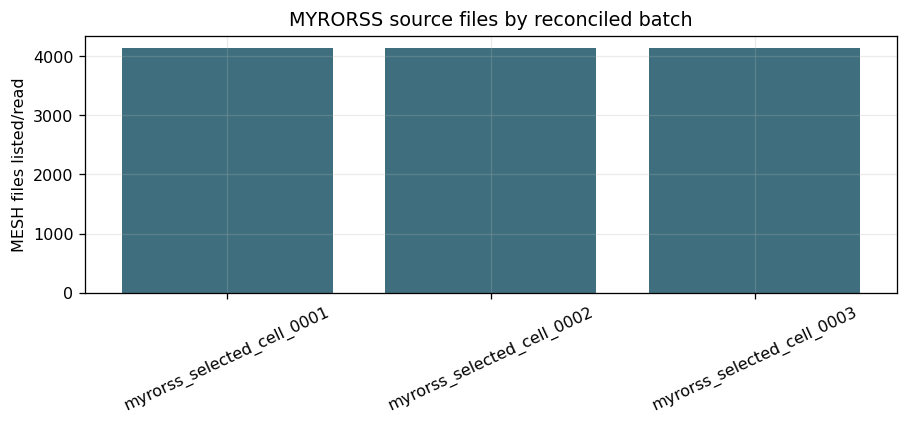

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(batch_manifest["batch_id"], batch_manifest["n_source_files"], color="#3f6f7f")
ax.set_title("MYRORSS source files by reconciled batch")
ax.set_ylabel("MESH files listed/read")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

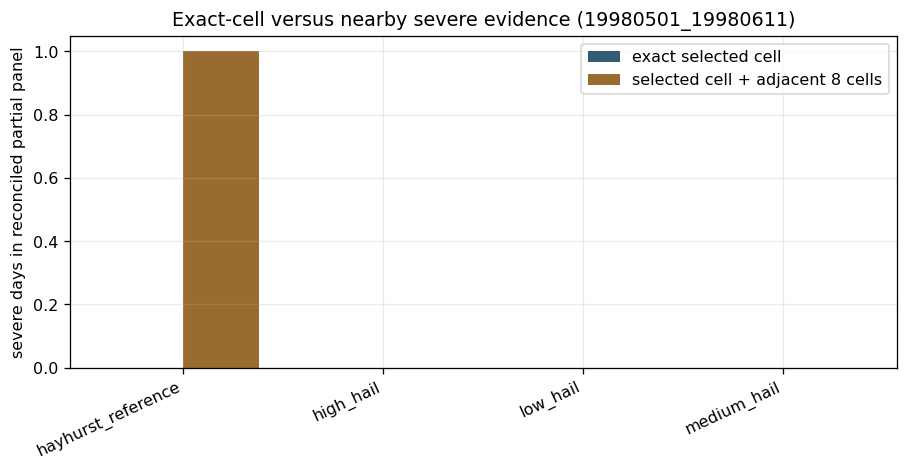

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_summary = selected_summary.sort_values("role")
x = np.arange(len(plot_summary))
width = 0.38
ax.bar(x - width / 2, plot_summary["n_myrorss_hail_days"], width, color="#315c72", label="exact selected cell")
ax.bar(
    x + width / 2,
    plot_summary["n_days_with_neighbor_3x3_severe_mesh"],
    width,
    color="#9a6b2f",
    label="selected cell + adjacent 8 cells",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_summary["role"], rotation=25, ha="right")
ax.set_ylabel("severe days in reconciled partial panel")
ax.set_title(f"Exact-cell versus nearby severe evidence ({RECON_LABEL})")
ax.legend()
plt.tight_layout()
plt.show()

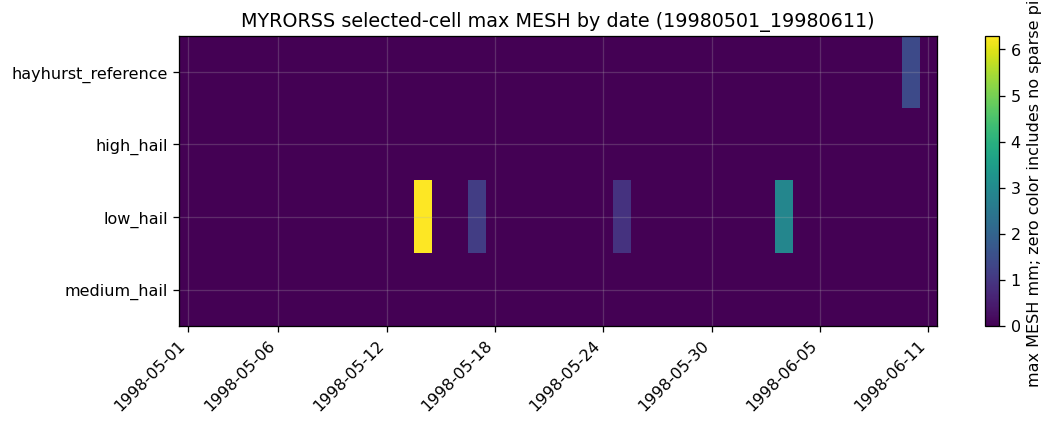

In [9]:
heat = reconciled_panel.pivot(index="role", columns="date", values="mesh_max_mm")
fig, ax = plt.subplots(figsize=(max(10, len(heat.columns) * 0.22), 3.8))
im = ax.imshow(heat.fillna(0), aspect="auto", cmap="viridis")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
tick_idx = np.linspace(0, len(heat.columns) - 1, min(8, len(heat.columns)), dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels([heat.columns[i] for i in tick_idx], rotation=45, ha="right")
ax.set_title(f"MYRORSS selected-cell max MESH by date ({RECON_LABEL})")
fig.colorbar(im, ax=ax, label="max MESH mm; zero color includes no sparse pixel")
plt.tight_layout()
plt.show()

## 7 - Write reconciled partial artifacts

These files are explicitly named `partial`. They are the right input for reviewing the reconciliation
contract and for later selected-cell M1 design, not a final MYRORSS climatology.

In [10]:
RECON_BATCH_MANIFEST_CSV = (
    HAIL_GRID_DIR / f"myrorss_m0_selected_cell_reconciled_batch_manifest_partial_{RECON_LABEL}_{OUTPUT_VERSION}.csv"
)
RECON_DATE_COVERAGE_CSV = (
    HAIL_GRID_DIR / f"myrorss_m0_selected_cell_reconciled_date_coverage_partial_{RECON_LABEL}_{OUTPUT_VERSION}.csv"
)
RECON_DAILY_PANEL_CSV = (
    HAIL_GRID_DIR / f"myrorss_m0_selected_cell_reconciled_daily_panel_partial_{RECON_LABEL}_{OUTPUT_VERSION}.csv"
)
RECON_SUMMARY_CSV = (
    HAIL_GRID_DIR / f"myrorss_m0_selected_cell_reconciled_summary_partial_{RECON_LABEL}_{OUTPUT_VERSION}.csv"
)
RECON_METADATA_JSON = (
    HAIL_GRID_DIR / f"myrorss_m0_selected_cell_reconciled_metadata_partial_{RECON_LABEL}_{OUTPUT_VERSION}.json"
)

batch_manifest.to_csv(RECON_BATCH_MANIFEST_CSV, index=False)
date_coverage.to_csv(RECON_DATE_COVERAGE_CSV, index=False)
reconciled_panel.to_csv(RECON_DAILY_PANEL_CSV, index=False)
selected_summary.to_csv(RECON_SUMMARY_CSV, index=False)

metadata = {
    "version": OUTPUT_VERSION,
    "hazard": "hail",
    "source": "MYRORSS",
    "source_product": "MESH/00.25",
    "stage": "M0 selected-cell reconciled partial panel",
    "selected_cells_path": relative(SELECTED_CELLS_CSV),
    "batch_plan_csv": relative(BATCH_PLAN_CSV),
    "reconciled_window": {
        "label": RECON_LABEL,
        "start": panel_start,
        "end": panel_end,
        "n_days": int(len(all_expected_dates)),
        "is_full_myrorss_record": False,
    },
    "accepted_batches": {
        "n_batches": int(len(batch_manifest)),
        "batch_labels": batch_manifest["batch_label"].tolist(),
        "batch_ids": batch_manifest["batch_id"].tolist(),
    },
    "reconcile_checks": {
        "n_selected_cells": int(len(selected_ids)),
        "n_daily_panel_rows": int(len(reconciled_panel)),
        "n_expected_daily_panel_rows": int(len(all_expected_dates) * len(selected_ids)),
        "n_duplicate_cell_date_rows": int(duplicate_panel_rows),
        "n_missing_dates": int(len(missing_dates)),
        "n_missing_cell_date_rows": int(len(missing_cell_dates)),
        "n_read_failures": int(reconciled_day_manifest["n_read_failures"].sum()),
        "n_source_files_total": int(reconciled_day_manifest["n_source_files"].sum()),
        "n_empty_source_files_total": int(reconciled_day_manifest["n_empty_source_files"].sum()),
        "n_exact_selected_cell_hail_days": int(reconciled_panel["hail_day_flag"].sum()),
        "n_neighbor_3x3_hail_days": int(reconciled_panel["neighbor_3x3_hail_day_flag"].sum()),
    },
    "outputs": {
        "batch_manifest_csv": relative(RECON_BATCH_MANIFEST_CSV),
        "date_coverage_csv": relative(RECON_DATE_COVERAGE_CSV),
        "daily_panel_csv": relative(RECON_DAILY_PANEL_CSV),
        "summary_csv": relative(RECON_SUMMARY_CSV),
    },
    "allowed_use": [
        "partial selected-cell MYRORSS evidence review",
        "reconciliation contract validation before larger batch campaigns",
        "input for selected-cell M1 design after enough source-era coverage exists",
    ],
    "not_allowed_use": [
        "final annual frequency",
        "final MYRORSS climatology",
        "MRMS replacement",
        "reportable EAL/PML/VaR/TVaR input",
    ],
    "caveats": [
        "Only completed clean planned batches are included.",
        "This is a partial 1998 MYRORSS-era panel, not the full 1998-2011 record.",
        "MYRORSS and MRMS are not assumed homogeneous.",
        "3x3-neighborhood diagnostics are QA context only, not exact-cell events.",
        "MESH bias and tail treatment remain unresolved.",
    ],
}
RECON_METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")

print("wrote:", RECON_BATCH_MANIFEST_CSV.relative_to(ROOT))
print("wrote:", RECON_DATE_COVERAGE_CSV.relative_to(ROOT))
print("wrote:", RECON_DAILY_PANEL_CSV.relative_to(ROOT))
print("wrote:", RECON_SUMMARY_CSV.relative_to(ROOT))
print("wrote:", RECON_METADATA_JSON.relative_to(ROOT))

wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_reconciled_batch_manifest_partial_19980501_19980611_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_reconciled_date_coverage_partial_19980501_19980611_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_reconciled_daily_panel_partial_19980501_19980611_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_reconciled_summary_partial_19980501_19980611_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_reconciled_metadata_partial_19980501_19980611_v2026_06_16.json


## 8 - Next step

The reconciliation gate now exists. The next step is to document the source-promotion gate before running
more batches:

```text
coverage denominator
  -> exact target vs neighborhood QA
  -> source-era comparability with MRMS
  -> MESH bias/de-bias status
  -> frequency/event definition
  -> tail-treatment status
```

After approved additional batches, rerun this reconciliation notebook. Move to GCP/Cloud Run style
orchestration only after the shared source job / adapter shape is explicit.